In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [3]:
# import STAGATE
from utils import Cal_Spatial_Net, Stats_Spatial_Net, mclust_R
from Train_STAGATE import train_STAGATE

In [4]:
section_list = ['151507', '151508', '151509', '151510']

In [5]:
adata_list = {}
for section_id in section_list:
    input_dir = os.path.join('../../../data/DLPFC', section_id)
    temp_adata = sc.read_visium(path=input_dir, count_file=section_id+'_filtered_feature_bc_matrix.h5')
    temp_adata.var_names_make_unique()

    Truth_df = pd.read_csv(os.path.join('../../../data/DLPFC', section_id, 'manual_annotations.txt'), sep='\t', header=None, index_col=0)
    temp_adata.obs['Ground Truth'] = Truth_df.loc[temp_adata.obs_names, 1]
    # make the spot name unique
    temp_adata.obs_names = [x+'_'+section_id for x in temp_adata.obs_names]

    adata_list[section_id] = temp_adata.copy()

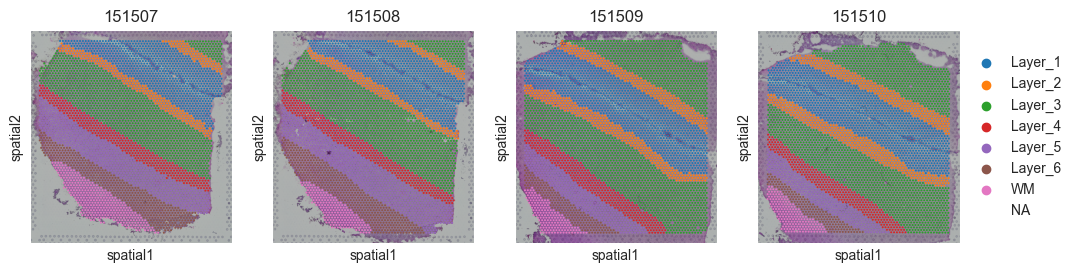

In [6]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
it=0
for section_id in section_list:
    if it == 3:
        sc.pl.spatial(adata_list[section_id], img_key="hires", ax=axs[it],
                      color=["Ground Truth"], title=section_id, show=False)
    else:
        sc.pl.spatial(adata_list[section_id], img_key="hires", ax=axs[it], legend_loc=None,
                      color=["Ground Truth"], title=section_id, show=False)
    it+=1

------Calculating spatial graph...
The graph contains 24770 edges, 4226 cells.
5.8613 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 25698 edges, 4384 cells.
5.8618 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 28172 edges, 4789 cells.
5.8826 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 27198 edges, 4634 cells.
5.8692 neighbors per cell on average.


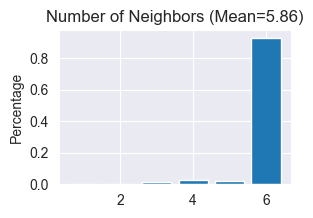

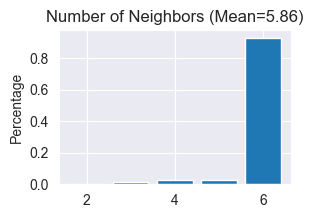

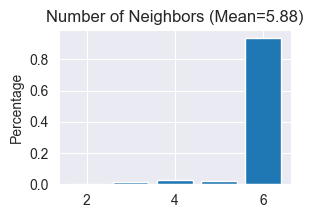

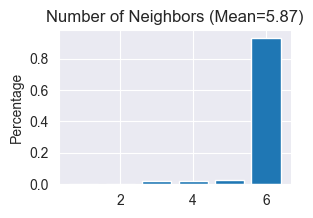

In [7]:
for section_id in section_list:
    Cal_Spatial_Net(adata_list[section_id], rad_cutoff=150)
    Stats_Spatial_Net(adata_list[section_id])

In [8]:
adata = sc.concat([adata_list[x] for x in section_list], keys=None)

In [9]:
adata.uns['Spatial_Net'] = pd.concat([adata_list[x].uns['Spatial_Net'] for x in section_list])

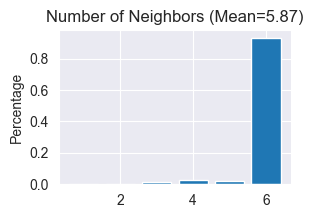

In [10]:
Stats_Spatial_Net(adata)

In [11]:
#Normalization
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [12]:
adata = train_STAGATE(adata)

Size of Input:  (18033, 2000)


100%|██████████| 1000/1000 [00:18<00:00, 53.69it/s]


In [13]:
adata.obs['Sample'] = [x.split('_')[-1] for x in adata.obs_names]

In [14]:
import harmonypy as hm

meta_data = adata.obs[['Sample']]

data_mat = adata.obsm['STAGATE']
vars_use = ['Sample']
ho = hm.run_harmony(data_mat, meta_data, vars_use)

res = pd.DataFrame(ho.Z_corr).T
res_df = pd.DataFrame(data=res.values, columns=['X{}'.format(i+1) for i in range(res.shape[1])], index=adata.obs.index)
adata.obsm[f'STAGATE.Harmony'] = res_df.to_numpy()

2025-08-05 17:14:25,396 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-08-05 17:14:28,104 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-05 17:14:28,201 - harmonypy - INFO - Iteration 1 of 10
2025-08-05 17:14:31,148 - harmonypy - INFO - Iteration 2 of 10
2025-08-05 17:14:32,494 - harmonypy - INFO - Iteration 3 of 10
2025-08-05 17:14:33,809 - harmonypy - INFO - Converged after 3 iterations


In [15]:
mclust_R(adata, used_obsm='STAGATE.Harmony', num_cluster=7)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 18033 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'Ground Truth', 'Sample', 'mclust'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'Spatial_Net', 'hvg', 'log1p'
    obsm: 'spatial', 'STAGATE', 'STAGATE.Harmony'

In [16]:
sub_adata = adata[~pd.isnull(adata.obs['Ground Truth'])]
ARI = ari_score(sub_adata.obs['Ground Truth'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
for name in section_list:
    sub_adata_tmp = sub_adata[sub_adata.obs['Sample'] == name]
    ARI = ari_score(sub_adata_tmp.obs['Ground Truth'], sub_adata_tmp.obs['mclust'])
    print(f"{name} ARI:{ARI}")

total ARI:0.5055630259084509
151507 ARI:0.507079628349584
151508 ARI:0.48771743478424356
151509 ARI:0.546640690924589
151510 ARI:0.5280182841525546


In [17]:
sub_adata = adata[~pd.isnull(adata.obs['Ground Truth'])]
NMI = nmi_score(sub_adata.obs['Ground Truth'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
AMI = ami_score(sub_adata.obs['Ground Truth'], sub_adata.obs['mclust'])
print(f"total AMI:{AMI}")
for name in section_list:
    sub_adata_tmp = sub_adata[sub_adata.obs['Sample'] == name]
    NMI = nmi_score(sub_adata_tmp.obs['Ground Truth'], sub_adata_tmp.obs['mclust'])
    AMI = ami_score(sub_adata_tmp.obs['Ground Truth'], sub_adata_tmp.obs['mclust'])
    ACC = 1/2 * (NMI + AMI)
    print(f"{name} ACC:{ACC}")

total NMI:0.6379544925902393
total AMI:0.6377468966090317
151507 ACC:0.6708594049836661
151508 ACC:0.6503058018502527
151509 ACC:0.6725586042605158
151510 ACC:0.6526549965142594


In [18]:
sub_adata = adata[~pd.isnull(adata.obs['Ground Truth'])]
HOM = hom_score(sub_adata.obs['Ground Truth'], sub_adata.obs['mclust'])
print(f"total HOM:{HOM}")
COM = com_score(sub_adata.obs['Ground Truth'], sub_adata.obs['mclust'])
print(f"total COM:{COM}")
for name in section_list:
    sub_adata_tmp = sub_adata[sub_adata.obs['Sample'] == name]
    HOM = hom_score(sub_adata_tmp.obs['Ground Truth'], sub_adata_tmp.obs['mclust'])
    COM = com_score(sub_adata_tmp.obs['Ground Truth'], sub_adata_tmp.obs['mclust'])
    V =  2 * ((HOM * COM) / (HOM + COM))
    print(f"{name} V:{V}")

total HOM:0.6422549197818607
total COM:0.6337112721764042
151507 V:0.6712558052005126
151508 V:0.6507177883899241
151509 V:0.6729275269893218
151510 V:0.6530697788204891


1.6626048493914183
1.1433937589535343


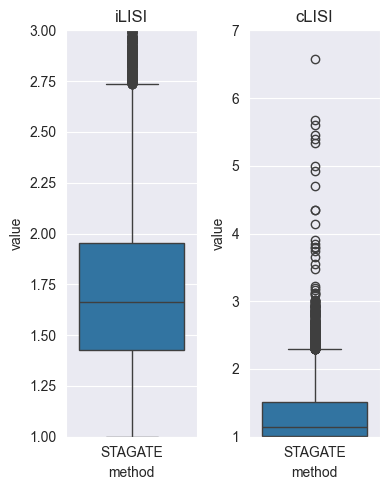

In [19]:
import harmonypy as hm

iLISI = hm.compute_lisi(adata.obsm['STAGATE'], adata.obs[['Sample']], label_colnames=['Sample'])[:, 0]
cLISI = hm.compute_lisi(adata.obsm['STAGATE'], adata.obs[['Ground Truth']], label_colnames=['Ground Truth'])[:, 0]
df_iLISI = pd.DataFrame({
    'method': 'STAGATE',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

df_cLISI = pd.DataFrame({
    'method': 'STAGATE',
    'value': cLISI,
    'type': ['CLISI'] * len(cLISI)
})

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
print(np.median(cLISI))

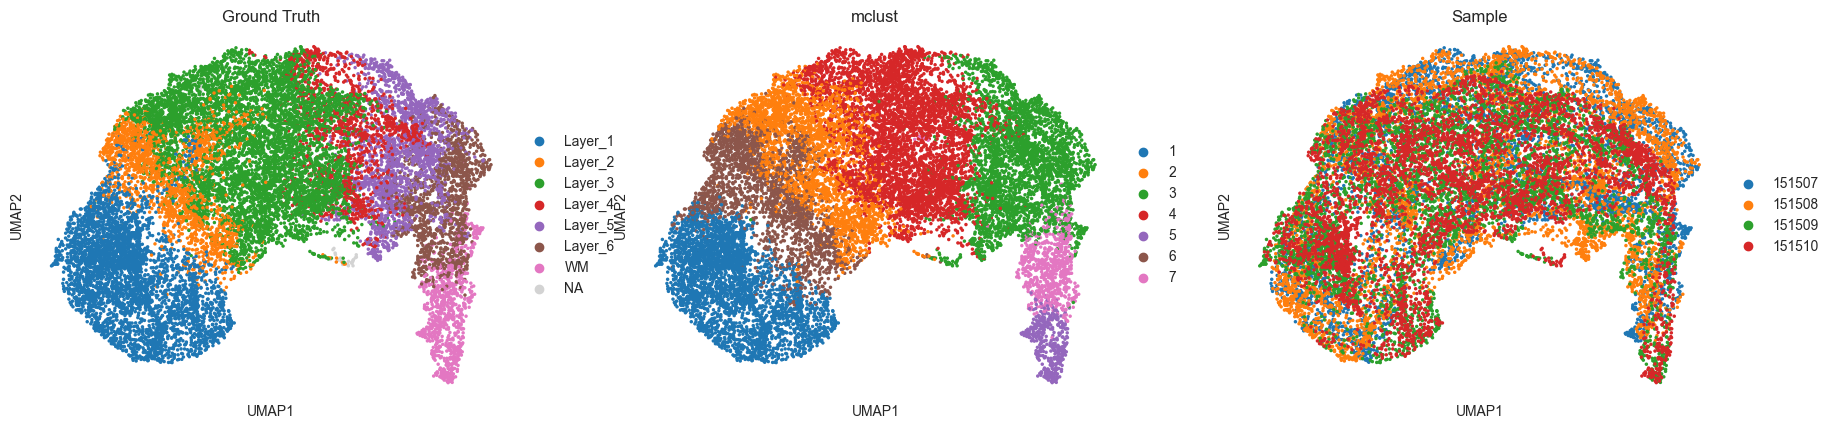

In [20]:
plt.rcParams['axes.facecolor'] = 'white'  # 设置子图的背景颜色
plt.rcParams['figure.facecolor'] = 'white'  # 设置整张图的背景颜色
# plt.rcParams['axes.facecolor'] = 'lightgray'  # 设置子图的背景颜色
# plt.rcParams['figure.facecolor'] = 'lightgray'  # 设置整张图的背景颜色

# %%
sc.pp.neighbors(adata, use_rep='STAGATE.Harmony', metric='cosine')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['Ground Truth', 'mclust', 'Sample'], show=True, size=25, save=False)

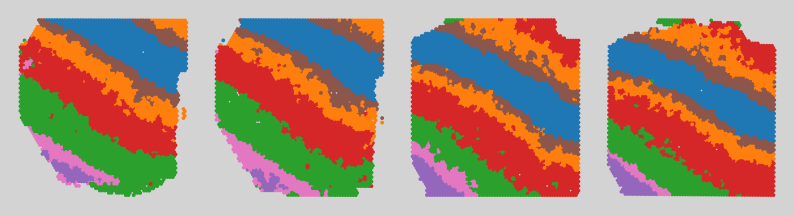

In [21]:
plt.rcParams['axes.facecolor'] = 'lightgray'  # 设置子图的背景颜色
plt.rcParams['figure.facecolor'] = 'lightgray'  # 设置整张图的背景颜色

Batch_list = []
for section_id in section_list:
    Batch_list.append(adata[adata.obs['Sample'] == section_id])

spot_size = 200
title_size = 12
ARI_list = []
# for bb in range(len(proj_list)):
#     ARI_list.append(round(ari_score(Batch_list[bb].obs['layer_guess'], Batch_list[bb].obs['mclust']), 3))
fig, ax = plt.subplots(1, 4, figsize=(10, 5), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})
for idx in range(len(section_list)):
    _sc_ = sc.pl.spatial(Batch_list[idx], img_key=None, color=['mclust'], title=[''],
                         legend_loc=None, legend_fontsize=12, show=False, ax=ax[idx], frameon=False,
                         spot_size=spot_size)
    # _sc_[0].set_title("ARI=" + str(ARI_list[idx]), size=title_size)
plt.show()